In [1]:
import sys

sys.path.append('../')

In [2]:
from src import simulation
from src import visualization

In [3]:
params = simulation.InvestmentParameters()

params.DELTA = .04
params.KAPPA = .3

In [4]:
env = simulation.InvestmentEnvironment(params)

Steady state capital: 8.16075642085437


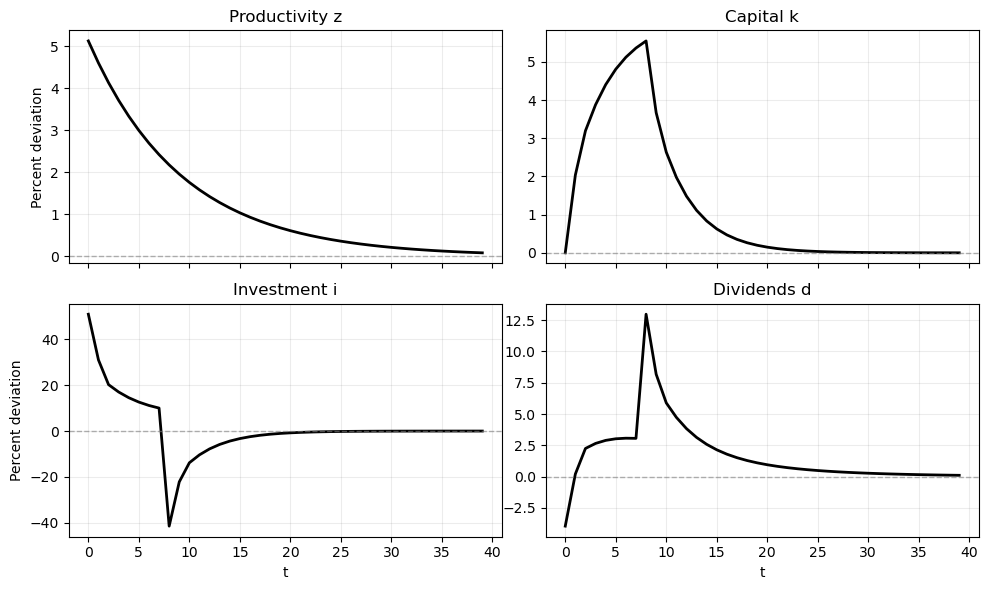

In [8]:
# ------------------------------
# 1. Parameters
# ------------------------------
params = simulation.InvestmentParameters(
    ALPHA=0.33,
    DELTA=0.04,
    R=0.04,
    SIGMA_EPS=0.02,   # must be > 0 for productivity IRF
    RHO=0.9,
    N_z=7,
    N_k=80,
    KAPPA = .3
)

# ------------------------------
# 2. Environment
# ------------------------------
env = simulation.InvestmentEnvironment(params, seed=0)

# ------------------------------
# 3. Rational Agent
# ------------------------------
rat = simulation.RationalInvestment(params).fit()

print("Steady state capital:", rat.fixed_point())

# ------------------------------
# 4. Run IRF
# ------------------------------
irf = rat.simulate_irf(
    env=env,
    T=40,
    shock_size_log=0.05,   # 5% productivity shock
    shock_time=0,
    deterministic_after=True
)

# ------------------------------
# 5. Plot IRF (percent deviations)
# ------------------------------
import matplotlib.pyplot as plt

t = irf["t"]
series = irf["pct"]

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
axes = axes.ravel()

labels = ["Productivity z", "Capital k", "Investment i", "Dividends d"]
keys = ["z", "k", "i", "d"]

for ax, key, label in zip(axes, keys, labels):
    ax.plot(t, series[key], linewidth=2.0, color="black")
    ax.axhline(0, color="gray", linestyle="--", linewidth=1.0, alpha=0.6)
    ax.set_title(label)
    ax.grid(True, color="gray", alpha=0.15, linewidth=0.8)

axes[2].set_xlabel("t")
axes[3].set_xlabel("t")
axes[0].set_ylabel("Percent deviation")
axes[2].set_ylabel("Percent deviation")

plt.tight_layout()
plt.show()

In [6]:
rat.fixed_point()

8.14040267957841

In [7]:
k_grid, pol_r = rat.policy_curve(rat.z_grid, rat.k_grid, z_idx=0)

NameError: name 'plt' is not defined

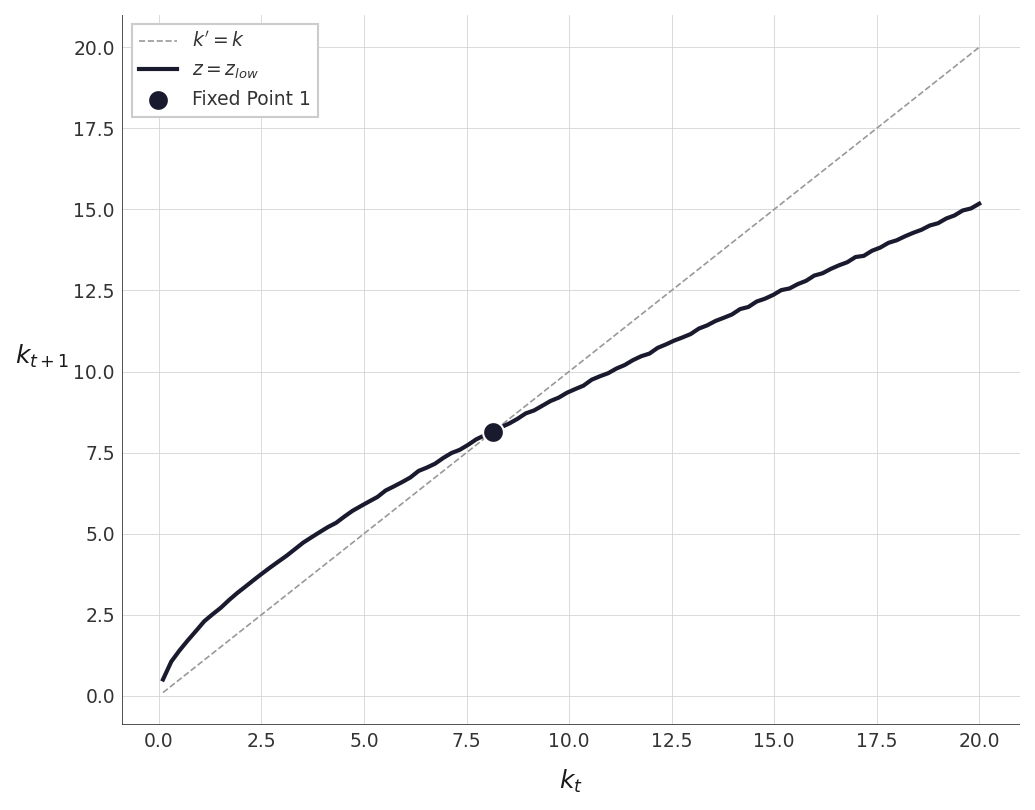

In [8]:
k_grid, pol_r = rat.policy_curve(rat.z_grid, rat.k_grid, z_idx=0)
# _, pol_r2 = rat.policy_curve(rat.z_grid, rat.k_grid, z_idx=2)

fig, ax = visualization.plot_phase(
    k_grid,
    [pol_r],
    [rat.fixed_point()],
    labels=[r"$z = z_{low}$", r"$z = z_{high}$"],
)
plt.show()

In [9]:

def simulate_irf(agent, p, T=40, shock_size_log=0.05,  # 5% log shock ≈ 5.13% level
                 z0=1.0, k0=None, shock_time=0):
    """
    Deterministic IRF (no further randomness): z follows AR(1) in logs with a one-time impulse.

    shock_size_log: impulse added to log(z) at shock_time.
    """
    if k0 is None:
        # deterministic steady state from Euler equation (linear utility, no adj costs)
        k0 = (p.ALPHA / (1.0 / p.BETA - (1.0 - p.DELTA))) ** (1.0 / (1.0 - p.ALPHA))

    t = np.arange(T)
    z_base = np.empty(T); z_shk = np.empty(T)
    k_base = np.empty(T); k_shk = np.empty(T)
    kp_base = np.empty(T); kp_shk = np.empty(T)
    i_base = np.empty(T); i_shk = np.empty(T)
    d_base = np.empty(T); d_shk = np.empty(T)

    # initialize
    z_base[0] = z0
    z_shk[0]  = z0
    k_base[0] = k0
    k_shk[0]  = k0

    # apply impulse to shocked path at shock_time
    if shock_time == 0:
        z_shk[0] = np.exp(np.log(z0) + shock_size_log)

    for tt in range(T):
        # policy (stationary agent uses same policy; learning agent may depend on t)
        kp_base[tt] = agent.policy_kprime(z_base[tt], k_base[tt], t=tt)
        kp_shk[tt]  = agent.policy_kprime(z_shk[tt],  k_shk[tt],  t=tt)

        i_base[tt] = kp_base[tt] - (1.0 - p.DELTA) * k_base[tt]
        i_shk[tt]  = kp_shk[tt]  - (1.0 - p.DELTA) * k_shk[tt]

        # dividends (linear utility version)
        d_base[tt] = z_base[tt] * (k_base[tt] ** p.ALPHA) - i_base[tt]
        d_shk[tt]  = z_shk[tt]  * (k_shk[tt]  ** p.ALPHA) - i_shk[tt]

        # transition to next period (if any)
        if tt < T - 1:
            # capital law of motion
            k_base[tt + 1] = kp_base[tt]
            k_shk[tt + 1]  = kp_shk[tt]

            # AR(1) in logs, deterministic (eps=0)
            z_base[tt + 1] = np.exp(p.RHO * np.log(z_base[tt]))
            z_shk[tt + 1]  = np.exp(p.RHO * np.log(z_shk[tt]))

            # apply impulse if shock_time > 0
            if tt + 1 == shock_time:
                z_shk[tt + 1] = np.exp(np.log(z_shk[tt + 1]) + shock_size_log)

    out = {
        "t": t,
        "base": {"z": z_base, "k": k_base, "i": i_base, "d": d_base},
        "shk":  {"z": z_shk,  "k": k_shk,  "i": i_shk,  "d": d_shk},
        "irf":  {
            "z": z_shk - z_base,
            "k": k_shk - k_base,
            "i": i_shk - i_base,
            "d": d_shk - d_base,
        },
        "irf_pct": {
            "z": 100.0 * (z_shk / z_base - 1.0),
            "k": 100.0 * (k_shk / k_base - 1.0),
            "i": 100.0 * (i_shk / i_base - 1.0),
            "d": 100.0 * (d_shk / d_base - 1.0),
        }
    }
    return out

In [ ]:
def plot_irf(irf_out, use_pct=True):
    t = irf_out["t"]
    series = irf_out["irf_pct"] if use_pct else irf_out["irf"]

    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
    axes = axes.ravel()

    keys = [("z", "Productivity z"),
            ("k", "Capital k"),
            ("i", "Investment i"),
            ("d", "Dividends d")]

    for ax, (k, title) in zip(axes, keys):
        ax.plot(t, series[k], linewidth=2.0, color="black")
        ax.axhline(0, color="gray", linewidth=1.0, linestyle="--", alpha=0.6)
        ax.set_title(title)
        ax.grid(True, color="gray", alpha=0.15, linewidth=0.8)

    axes[2].set_xlabel("t")
    axes[3].set_xlabel("t")

    ylab = "Percent deviation" if use_pct else "Deviation"
    axes[0].set_ylabel(ylab)
    axes[2].set_ylabel(ylab)

    plt.tight_layout()

    plt.show()

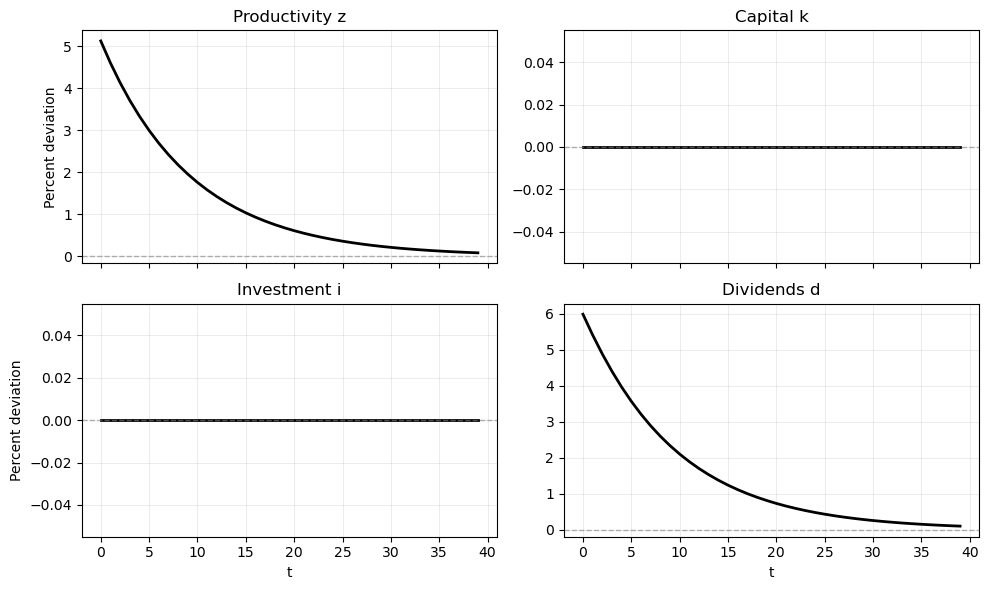

In [17]:
import numpy as np
import matplotlib.pyplot as plt
irf_out = simulate_irf(rat, params, T=40, shock_size_log=0.05, shock_time=0)
plot_irf(irf_out, use_pct=True)